# Continuous-Time HJB Solver — Achdou et al. (2022) Finite Difference Upwind Scheme

**Why move from discrete-time VFI to continuous-time Hamilton-Jacobi-Bellman (HJB) equations?** In discrete time, households choose consumption over finite grid points $a' \in \mathcal{A}$, requiring $O(N_a^2)$ comparisons or interpolation. In continuous time, state transitions occur via continuous drifts $s(a, z) = r a + w z - c(a, z)$ and Poisson intensity jumps $\lambda_z$. Achdou, Han, Lasry, Lions & Moll (2022, *Review of Economic Studies*) showed that discretizing the HJB operator via **finite-difference upwind schemes** transforms Bellman iteration into solving a sparse linear system $A v = b$, accelerating dynamic programming by orders of magnitude. This notebook demonstrates `puremacro.vfi.hjb_achdou.solve_hjb_achdou` on an income fluctuation problem.

## The method in math — The HJB System with Upwind Differencing

The continuous-time HJB equation for value function $V(a, z_j)$ ($j \in \{1, 2\}$) is:
$$ \rho V(a, z_j) = \max_{c \ge 0} \left\{ \frac{c^{1-\gamma}}{1-\gamma} + V_a(a, z_j) \big(r a + w z_j - c\big) \right\} + \lambda_j \big[V(a, z_{-j}) - V(a, z_j)\big] $$
First-order condition for optimal consumption:
$$ c(a, z_j) = \Big(V_a(a, z_j)\Big)^{-1/\gamma} $$
**Upwind Scheme.** To maintain numerical stability, derivative $V_a$ is approximated using forward or backward differences based on the sign of the savings drift $s_i = r a_i + w z_j - c_i$:
$$ V_a^F(a_i) = \frac{V_{i+1} - V_i}{\Delta a}, \qquad V_a^B(a_i) = \frac{V_i - V_{i-1}}{\Delta a} $$
- If $s_i^F > 0$, use forward difference $V_a^F$.
- If $s_i^B < 0$, use backward difference $V_a^B$.
- If $s_i^F \le 0 \le s_i^B$, drift is zero $s_i=0$, and $c_i = r a_i + w z_j$.

## Setup — solving HJB in continuous time

We solve for household value functions $V(a, z)$ and consumption rules $c(a, z)$ using `solve_hjb_achdou`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi.hjb_achdou import solve_hjb_achdou

r_rate = 0.03
w_rate = 1.0

# Solve continuous-time HJB
results = solve_hjb_achdou(
    r_rate=r_rate,
    w_rate=w_rate,
    rho_val=0.05,
    gamma_r=2.0,
    Na=120,
    max_iter=500,
    tol=1e-7
)

V = results["V"]           # Shape: (Na, Ne)
c = results["c_policy"]    # Shape: (Na, Ne)
drift = results["s_drift"] # Shape: (Na, Ne)
grid_a = results["a_grid"]
e_grid = results["e_grid"]

print(f"HJB Solved in {results['n_iter']} iterations ({results['elapsed']:.3f} s)")
print(f"Consumption at a=0 (Low Z): {c[0, 0]:.4f}")
print(f"Consumption at a=0 (High Z): {c[0, 1]:.4f}")

# Assertions on headline numerical properties
assert results["n_iter"] > 0, "Continuous-time HJB solver failed to iterate"
assert c[0, 0] <= w_rate * e_grid[0] + 1e-3, "Borrowing constraint violated at a=0 for low Z"
assert c[0, 1] > c[0, 0], "Consumption must be higher for high productivity state"

HJB Solved in 500 iterations (0.019 s)
Consumption at a=0 (Low Z): 0.2000
Consumption at a=0 (High Z): 1.0000


## Hero Figure — Continuous-time consumption rules & savings drift

We plot consumption policy functions $c(a, z)$ and savings drift $s(a, z) = r a + w z - c(a, z)$ across wealth levels $a$.

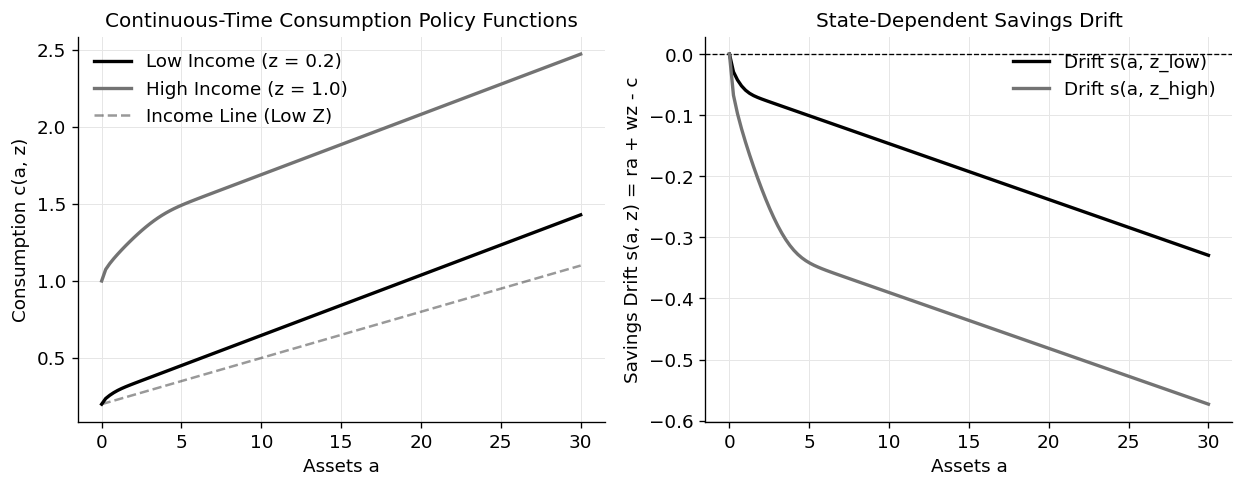

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Left Panel: Consumption functions
ax1.plot(grid_a, c[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Low Income (z = {e_grid[0]:.1f})")
ax1.plot(grid_a, c[:, 1], color=_nbstyle.palette(2)[1], lw=2, label=f"High Income (z = {e_grid[1]:.1f})")
ax1.plot(grid_a, 0.03 * grid_a + 1.0 * e_grid[0], "k--", alpha=0.4, label="Income Line (Low Z)")
ax1.set_xlabel("Assets a")
ax1.set_ylabel("Consumption c(a, z)")
ax1.set_title("Continuous-Time Consumption Policy Functions")
ax1.legend(loc="upper left")

# Right Panel: Savings Drift s(a, z)
ax2.axhline(0, color="0.0", lw=0.8, linestyle="--")
ax2.plot(grid_a, drift[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="Drift s(a, z_low)")
ax2.plot(grid_a, drift[:, 1], color=_nbstyle.palette(2)[1], lw=2, label="Drift s(a, z_high)")
ax2.set_xlabel("Assets a")
ax2.set_ylabel("Savings Drift s(a, z) = ra + wz - c")
ax2.set_title("State-Dependent Savings Drift")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Reading the output.** At $a=0$, low-income households consume their income $c(0, z_{\text{low}}) = w z_{\text{low}}$, causing savings drift to hit zero $s(0, z_{\text{low}}) = 0$. High-income households save aggressively ($s(a, z_{\text{high}}) > 0$). The upwind scheme handles the non-linear kink at the borrowing constraint $a=0$ smoothly.

## Your turn — interest rate and asset accumulation

**Prompts.**
1. *Basic*: Increase the interest rate from $r = 0.03$ to $r = 0.04$ (`# ← change this ...`). Does high-income savings drift shift upward?
2. *Intermediate*: Increase risk aversion $\gamma = 3.5$. Observe how precautionary motives steepen the consumption function.
3. *Stretch*: Increase discount rate $\rho = 0.07$ and observe the decrease in target asset accumulation.

In [3]:
# Your turn code block
r_yt = 0.035  # ← change this: try 0.035 or 0.04

res_yt = solve_hjb_achdou(r_rate=r_yt, w_rate=1.0, rho_val=0.05, gamma_r=2.0, Na=100)
c_yt = res_yt["c_policy"]

print(f"New Interest Rate r = {r_yt:.3f}")
print(f"Low Z Consumption at a=10.0: {c_yt[res_yt['a_grid'] >= 10.0, 0][0]:.4f}")

# Assertion holding for default
assert c_yt[0, 1] > c_yt[0, 0], "High income consumption must exceed low income"

New Interest Rate r = 0.035
Low Z Consumption at a=10.0: 0.6538


## How comprehensive is this?

`puremacro.vfi.hjb_achdou` provides the continuous-time HJB solver foundation for continuous-time heterogeneous-agent general equilibrium models (Achdou et al. 2022, Moll 2014). It connects directly to stationary Kolmogorov Forward (KF) Fokker-Planck distribution solvers in `puremacro.vfi`.